
# RNN / LSTM Language Modeling

*A lecture note on giving language models a memory: from the vanilla
recurrent neural network to the LSTM that fixed it.*

---

## 1. Intro: the problem with only ever looking at the last few words

If you've been through this domain's **n-gram language models** tutorial,
you've seen the classic statistical approach to "predict the next word":
count how often each word follows the previous $n-1$ words, and use those
counts as probabilities. It works, and it's cheap — but it has a hard,
built-in ceiling. A **trigram** model ($n=3$) predicting the next word after

> "...After spending the entire morning searching every drawer in the old
> oak **desk**, Alice finally found the key she had been looking..."

only ever sees the last two words, `"looking for"` — it has *already
forgotten* that the key opens a **desk**, that it was found after a long
**search**, everything. The word 40 tokens back might be exactly the
context that matters, and a fixed-window model structurally cannot use it.
You could widen the window, but the number of possible $n$-grams explodes
combinatorially long before you get anywhere near "40 words of context,"
and most of those n-grams would never be seen twice in any real corpus
(the same **data sparsity** wall the n-gram tutorial hits).

This tutorial covers the neural fix: a model whose "memory" isn't a fixed
window at all, but a running summary vector that gets updated one word at
a time and — in principle — can carry information from arbitrarily far
back in the sequence. That's a **recurrent neural network (RNN)**. We'll
see why the simplest version of this idea doesn't actually deliver on that
promise in practice (the **vanishing gradient problem**), and how the
**LSTM (Long Short-Term Memory)** architecture fixes it well enough to have
been the dominant language-modeling architecture for roughly two decades —
right up until Transformers (this domain's own
**transformer-self-attention** tutorial) took over.

By the end of this notebook you'll be able to:
- Write down the vanilla RNN recurrence and explain, with the actual
  chain-rule math, why it struggles with long sequences.
- Write down the LSTM's gate and cell-state equations and explain why an
  *additive* update helps.
- Train a real character-level LSTM language model on real text in
  PyTorch, watch its loss and perplexity actually drop over real training
  epochs, and generate new text from it — including seeing what
  "temperature" does to generation.



## 2. The idea, intuitively

Think of reading a novel. You don't re-read the last two words before
guessing what comes next — you carry a mental summary of *everything
relevant so far* (who the characters are, what just happened, the tone of
the scene) and you update that summary a little with every new word you
read. That running summary is what a recurrent neural network calls its
**hidden state**, usually written $h_t$ (the summary *after* reading the
$t$-th token).

At every timestep, an RNN does the same simple thing:

> **new hidden state = some function of (old hidden state, current input word)**

Critically, it's the *same* function, with the *same* learned weights,
reused at every position in the sequence — that's what makes it
"recurrent." Because $h_t$ is built from $h_{t-1}$, which was built from
$h_{t-2}$, and so on back to the start of the sequence, information from
step 1 can — in principle — still influence the prediction at step 100.
No fixed window, no combinatorial blow-up: just one vector, updated in
place, one word at a time.

Let's see that "in principle" claim actually hold up on a toy example
before writing any formal math. Below, we hand-roll a single RNN step and
feed it two six-word sequences that are identical except for **one word,
four positions from the end** — token 2 out of 6.


In [1]:

import numpy as np

np.random.seed(0)

vocab = {"the": 0, "cat": 1, "dog": 2, "sat": 3, "on": 4, "mat": 5}
hidden_dim = 4

W_xh = np.random.randn(hidden_dim, len(vocab)) * 0.5
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.5
b_h = np.zeros(hidden_dim)

def rnn_step(h_prev, x_onehot):
    # One vanilla-RNN update: h_t = tanh(W_hh h_{t-1} + W_xh x_t + b_h)
    return np.tanh(W_hh @ h_prev + W_xh @ x_onehot + b_h)

def run_rnn(tokens):
    h = np.zeros(hidden_dim)
    for tok in tokens:
        x = np.zeros(len(vocab))
        x[vocab[tok]] = 1.0
        h = rnn_step(h, x)
    return h

seq_a = ["the", "cat", "sat", "on", "the", "mat"]   # word 2 = "cat"
seq_b = ["the", "dog", "sat", "on", "the", "mat"]   # word 2 = "dog", everything else identical

h_a = run_rnn(seq_a)
h_b = run_rnn(seq_b)

print("Hidden state after '...cat sat on the mat':", np.round(h_a, 3))
print("Hidden state after '...dog sat on the mat':", np.round(h_b, 3))
print(f"\nDifference in final hidden state: {np.linalg.norm(h_a - h_b):.4f}")
print("(nonzero, four steps later -- the word from position 2 is still")
print(" influencing the hidden state used to predict position 7)")


Hidden state after '...cat sat on the mat': [-0.354  0.973 -0.843  0.603]
Hidden state after '...dog sat on the mat': [-0.351  0.973 -0.843  0.606]

Difference in final hidden state: 0.0038
(nonzero, four steps later -- the word from position 2 is still
 influencing the hidden state used to predict position 7)



The two sequences share every token except the second one, yet the final
hidden state — the one that would be used to predict the *next* word — is
still measurably different four steps later. A trigram model conditioning
only on `"on", "the"` would produce **the exact same prediction** for both
sequences, since its context window doesn't reach back to position 2 at
all. The RNN's hidden state, by contrast, is a compressed summary of the
*entire* sequence so far, not a fixed window.

**That's the whole idea.** Everything from here is (a) writing that update
rule down formally, (b) discovering that vanilla RNNs are much worse at
this "remember far back" job than the toy example suggests once sequences
get long, and (c) fixing that with the LSTM.



## 3. Going deeper: the formal definitions

### 3.1 The vanilla RNN, precisely

At each timestep $t$, given input $x_t$ (e.g. a one-hot or embedded word
vector) and the previous hidden state $h_{t-1}$, a vanilla RNN computes:

$$
h_t = \tanh\big(W_{hh} h_{t-1} + W_{xh} x_t + b_h\big)
$$

and, if we want a prediction at this step (e.g. "what's the next word"):

$$
\hat{y}_t = \text{softmax}\big(W_{hy} h_t + b_y\big)
$$

where $W_{hh} \in \mathbb{R}^{d_h \times d_h}$, $W_{xh} \in \mathbb{R}^{d_h
\times d_x}$, $W_{hy} \in \mathbb{R}^{|V| \times d_h}$ are learned weight
matrices (shared across *every* timestep — this is what "recurrent" means
architecturally), $b_h, b_y$ are learned biases, $d_h$ is the hidden size,
$d_x$ the input embedding size, and $|V|$ the vocabulary size. $h_0$ is
typically initialized to the zero vector. Training minimizes the total
cross-entropy loss $L = \sum_t L_t$ over predicted-vs-actual next tokens,
via **backpropagation through time (BPTT)**: literally unroll the
recurrence into a very deep feed-forward computation graph (one "layer"
per timestep) and run ordinary backprop through it.

### 3.2 Why vanilla RNNs struggle with long-range dependencies

Here's where it breaks. To update $W_{hh}$, we need $\partial L_t /
\partial h_k$ for early timesteps $k \ll t$ — how much did the hidden
state *many steps ago* affect the loss *now*. By the chain rule:

$$
\frac{\partial L_t}{\partial h_k} = \frac{\partial L_t}{\partial h_t}
\cdot \prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}
$$

and for a single step, differentiating $h_i = \tanh(W_{hh} h_{i-1} +
W_{xh}x_i + b_h)$ with respect to $h_{i-1}$:

$$
\frac{\partial h_i}{\partial h_{i-1}} = \text{diag}\big(\tanh'(z_i)\big)\, W_{hh},
\qquad z_i = W_{hh}h_{i-1} + W_{xh}x_i + b_h
$$

Writing out the chain over just 3 steps ($k=t-3$) makes the pattern
obvious — it's a straight product of the *same* matrix $W_{hh}$, three
times, interleaved with three $\tanh'$ diagonal terms:

$$
\frac{\partial h_t}{\partial h_{t-3}} =
\underbrace{\text{diag}(\tanh'(z_t))\,W_{hh}}_{\text{step }t}\;
\underbrace{\text{diag}(\tanh'(z_{t-1}))\,W_{hh}}_{\text{step }t-1}\;
\underbrace{\text{diag}(\tanh'(z_{t-2}))\,W_{hh}}_{\text{step }t-2}
$$

For a gap of $t - k$ steps, this is a product of $t-k$ copies of
$W_{hh}$ interleaved with $t-k$ derivative terms. Two facts now compound:

1. **$\tanh'(z) = 1 - \tanh(z)^2 \le 1$ always**, and is close to $0$
   whenever $\tanh(z)$ is saturated near $\pm 1$ (which happens often once
   the network is at all confident about anything).
2. Repeatedly multiplying by the *same* matrix $W_{hh}$ scales the
   gradient by (roughly) its largest singular value $\sigma_{\max}$ on
   every step.

So the norm of this product is bounded by roughly $\big(\sigma_{\max}
\cdot \max|\tanh'|\big)^{t-k}$ — **something raised to the power of the
gap length**. If that base is even slightly less than 1 (extremely
common, since $\tanh'\le 1$ pulls it down even when $\sigma_{\max}$ isn't
small), the gradient shrinks **exponentially** with sequence length. By
the time $t - k$ reaches even a few dozen steps, $\partial L_t/\partial
h_k$ is numerically indistinguishable from zero — the network receives
*no usable learning signal* about how the input 30+ steps back should
have been treated differently. This is the **vanishing gradient problem**
(Bengio, Simard & Frasconi, 1994; Hochreiter, 1991). The symmetric failure
mode — if $\sigma_{\max}$ is large instead — is **exploding** gradients,
which is a real but comparatively easy problem to patch (gradient
clipping). Vanishing gradients require an architectural fix, which is
exactly what the LSTM is.

### 3.3 The LSTM: an additive path for gradients

Hochreiter & Schmidhuber (1997) fixed this not by tweaking $\tanh$ or the
learning rate, but by changing what gets multiplied at all. The LSTM
keeps a second recurrent quantity, the **cell state** $C_t$, alongside the
hidden state $h_t$, and updates it through three learned **gates** — each
a sigmoid ($\sigma$, output in $[0,1]$) acting as a soft "how much to let
through" switch — plus a candidate update:

$$
\begin{aligned}
f_t &= \sigma\big(W_f [h_{t-1}, x_t] + b_f\big) &&\text{forget gate}\\
i_t &= \sigma\big(W_i [h_{t-1}, x_t] + b_i\big) &&\text{input gate}\\
o_t &= \sigma\big(W_o [h_{t-1}, x_t] + b_o\big) &&\text{output gate}\\
\tilde{C}_t &= \tanh\big(W_C [h_{t-1}, x_t] + b_C\big) &&\text{candidate cell content}\\[4pt]
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t &&\text{cell state update}\\
h_t &= o_t \odot \tanh(C_t) &&\text{hidden state (output)}
\end{aligned}
$$

where $[h_{t-1}, x_t]$ denotes concatenation and $\odot$ is elementwise
multiplication. Each gate has its own weight matrix and is a full sigmoid
layer over the same inputs, so the network *learns* how open each gate
should be, per unit, per timestep.

**Why this helps with the vanishing gradient, concretely:** look at the
cell-state update — it is *additive*: $C_t = f_t \odot C_{t-1} + (\cdots)$.
Differentiating with respect to $C_{t-1}$:

$$
\frac{\partial C_t}{\partial C_{t-1}} = f_t
$$

— an **elementwise multiplication by the forget gate**, not a matrix
multiplication by a shared weight matrix $W_{hh}$ passed through a
saturating $\tanh'$. If a unit needs to remember something for a long
time, the network can simply learn $f_t \approx 1$ for that unit, and the
gradient $\partial C_t/\partial C_{t-1}$ passes through **almost
unchanged**, timestep after timestep — a near-constant, directly
controllable path, rather than a chain of $t-k$ multiplications by a
fixed matrix that shrinks by construction. This is often called the
**constant error carousel**. It is a genuine architectural fix: gradients
now have a route through the network that doesn't automatically decay
with distance. It is **not** a complete cure — $f_t$ is a sigmoid, so it's
never *exactly* 1, other paths (through $i_t, o_t, \tilde C_t$, and $h_t$
itself) still involve saturating nonlinearities, and in practice LSTMs
still degrade on very long sequences. But the difference between "decays
by construction, always" and "decays only if the network fails to learn
$f_t\approx 1$" is large enough that it made long-range language modeling
practical for the first time. We'll see this difference in a small,
illustrative simulation next.



## 4. Visuals: watching gradients vanish (and not)

Two small, purely illustrative simulations — not trained models — to make
§3.2 and §3.3 concrete: first, the derivative of $\tanh$ itself and why it
caps every step's multiplier at 1; second, a toy backprop-through-time
simulation comparing how a gradient signal decays across many timesteps
for the vanilla-RNN multiplicative path versus the LSTM's additive
forget-gate path.


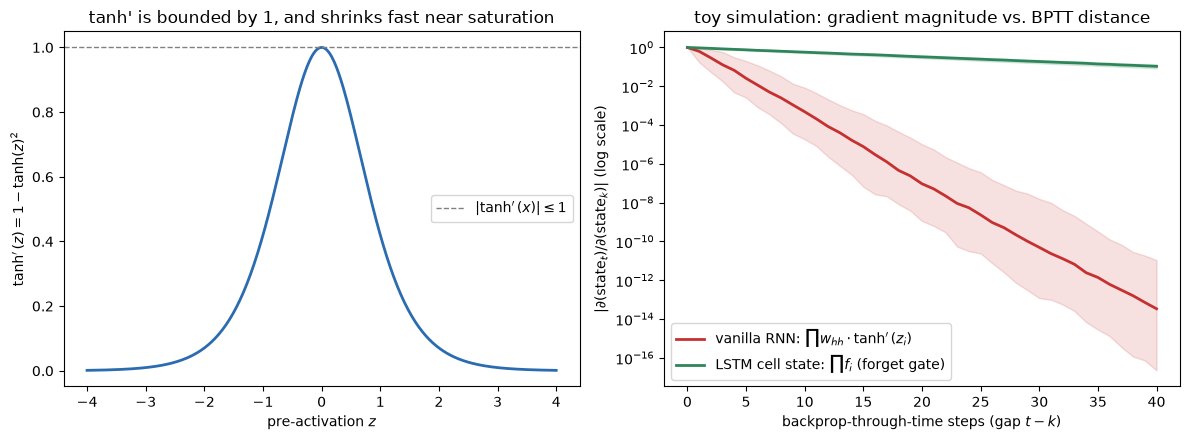

Median vanilla-RNN gradient magnitude after 40 steps: 3.40e-14
Median LSTM cell-state gradient magnitude after 40 steps: 1.07e-01


In [2]:

import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 400)
tanh_prime = 1 - np.tanh(x) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x, tanh_prime, color="#2b6cb0", linewidth=2)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1, label=r"$|\tanh^{\prime}(x)| \leq 1$")
axes[0].set_xlabel(r"pre-activation $z$")
axes[0].set_ylabel(r"$\tanh^{\prime}(z) = 1-\tanh(z)^2$")
axes[0].set_title("tanh' is bounded by 1, and shrinks fast near saturation")
axes[0].legend()

# --- Toy BPTT gradient-magnitude simulation ---------------------------------
rng = np.random.default_rng(7)
n_steps = 40
n_trials = 200

# Vanilla RNN path: at each step, gradient is multiplied by (recurrent weight * tanh').
# Use a recurrent "weight" w=0.95 (a generous, near-1 case) and random pre-activations
# so tanh'(z) is drawn from what a real network sees (mix of near-0 and near-1).
w_hh = 0.95
vanilla_paths = np.ones((n_trials, n_steps + 1))
for trial in range(n_trials):
    z = rng.normal(0, 1.0, size=n_steps)
    factors = w_hh * (1 - np.tanh(z) ** 2)
    vanilla_paths[trial, 1:] = np.cumprod(factors)

# LSTM additive path: dC_t/dC_{t-1} = f_t, a learned sigmoid gate. A network that
# has learned "remember this" pushes forget-gate pre-activations positive/large;
# simulate f_t drawn from sigmoid(Uniform(2, 4)) => f_t roughly in [0.88, 0.98].
lstm_paths = np.ones((n_trials, n_steps + 1))
for trial in range(n_trials):
    gate_preact = rng.uniform(2.0, 4.0, size=n_steps)
    f_t = 1 / (1 + np.exp(-gate_preact))
    lstm_paths[trial, 1:] = np.cumprod(f_t)

steps = np.arange(n_steps + 1)
vanilla_median = np.median(vanilla_paths, axis=0)
lstm_median = np.median(lstm_paths, axis=0)

axes[1].semilogy(steps, vanilla_median, color="#c53030", linewidth=2,
                  label=r"vanilla RNN: $\prod w_{hh}\cdot\tanh^{\prime}(z_i)$")
axes[1].semilogy(steps, lstm_median, color="#2f855a", linewidth=2,
                  label=r"LSTM cell state: $\prod f_i$ (forget gate)")
axes[1].fill_between(steps, np.percentile(vanilla_paths, 10, axis=0),
                      np.percentile(vanilla_paths, 90, axis=0), color="#c53030", alpha=0.15)
axes[1].fill_between(steps, np.percentile(lstm_paths, 10, axis=0),
                      np.percentile(lstm_paths, 90, axis=0), color="#2f855a", alpha=0.15)
axes[1].set_xlabel("backprop-through-time steps (gap $t-k$)")
axes[1].set_ylabel(r"$|\partial(\text{state}_t)/\partial(\text{state}_k)|$ (log scale)")
axes[1].set_title("toy simulation: gradient magnitude vs. BPTT distance")
axes[1].legend()

plt.tight_layout()
plt.savefig("gradient_vanishing.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Median vanilla-RNN gradient magnitude after 40 steps: {vanilla_median[-1]:.2e}")
print(f"Median LSTM cell-state gradient magnitude after 40 steps: {lstm_median[-1]:.2e}")



Even in this generous setup for the vanilla RNN — a recurrent weight of
$0.95$, which is *smaller than 1* on its own, before any $\tanh'$ shrinkage
is even applied — the gradient magnitude collapses to something
numerically negligible within a few dozen steps, because it's a product of
$\le 1$ terms compounding every single timestep. The LSTM's forget-gate
path, sampled from gate values a well-trained "remember this" unit would
plausibly learn ($f_t \approx 0.9$–$0.98$), decays far more slowly across
the same number of steps — not flat (it's still a product of numbers
below 1, so it does eventually shrink too — this is *mitigation*, not
elimination), but the network has direct, learnable control over how slow
that decay is, unit by unit, instead of it being forced by a shared weight
matrix and $\tanh'$ on every single step.



## 5. Implementation: a real character-level LSTM language model

We'll train a real `torch.nn.LSTM` language model, cross-entropy loss and
Adam optimizer, on real text: Lewis Carroll's *Alice's Adventures in
Wonderland*, via NLTK's Gutenberg corpus. We work at the **character**
level (predict the next character, not the next word) — this keeps the
vocabulary tiny (~70 symbols instead of tens of thousands of words), which
matters a lot on a CPU-only machine with a real time budget, and it's the
exact setup Karpathy's *Unreasonable Effectiveness of RNNs* (2015) post
and Graves' (2013) sequence-generation paper made famous: the model has to
learn spelling, punctuation, and word boundaries from scratch, purely from
next-character prediction.

### 5.1 Load and prepare the corpus


In [3]:

import re
from nltk.corpus import gutenberg

raw_text = gutenberg.raw("carroll-alice.txt")
text = re.sub(r"\s+", " ", raw_text).strip()  # collapse all whitespace runs to single spaces

print(f"Loaded 'Alice's Adventures in Wonderland' (Carroll, 1865): {len(text):,} characters")
print(text[:300])


Loaded 'Alice's Adventures in Wonderland' (Carroll, 1865): 142,451 characters
[Alice's Adventures in Wonderland by Lewis Carroll 1865] CHAPTER I. Down the Rabbit-Hole Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations


In [4]:

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print(f"Character vocabulary size: {vocab_size}")
print("Vocabulary:", "".join(chars))

import torch

data = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)

split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"\nTrain characters: {len(train_data):,}   Val characters: {len(val_data):,}")


Character vocabulary size: 72
Vocabulary:  !"'()*,-.1568:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyz



Train characters: 128,205   Val characters: 14,246



### 5.2 Batching

We cut the character stream into fixed-length chunks of `seq_len`
consecutive characters. For each chunk, the model's target at every
position is simply *the next character* (the whole sequence shifted by
one) — that's what "next-token prediction" means concretely.


In [5]:

seq_len = 100
batch_size = 64

def get_batches(data, seq_len, batch_size, shuffle=True):
    n_chunks = (len(data) - 1) // seq_len
    xs = data[: n_chunks * seq_len].view(n_chunks, seq_len)
    ys = data[1 : n_chunks * seq_len + 1].view(n_chunks, seq_len)
    order = torch.randperm(n_chunks) if shuffle else torch.arange(n_chunks)
    for start in range(0, n_chunks - batch_size + 1, batch_size):
        idx = order[start : start + batch_size]
        yield xs[idx], ys[idx]

# sanity check: one batch's shapes, and that targets really are inputs shifted by one
xb, yb = next(get_batches(train_data, seq_len, batch_size))
print("Input batch shape:", xb.shape, " Target batch shape:", yb.shape)
print("Example input chars: ", "".join(itos[i.item()] for i in xb[0][:20]))
print("Example target chars:", "".join(itos[i.item()] for i in yb[0][:20]))


Input batch shape: torch.Size([64, 100])  Target batch shape: torch.Size([64, 100])
Example input chars:  OUS nose'; as an unu
Example target chars: US nose'; as an unus



### 5.3 The model

Straightforward: an embedding layer maps each character index to a dense
vector ($x_t$ in §3.1's notation), `nn.LSTM` runs the real gated
recurrence from §3.3 across the sequence, and a final linear layer maps
each timestep's hidden state $h_t$ to a distribution over the next
character ($W_{hy}h_t + b_y$ from §3.1, applied at every position).


In [6]:

import torch.nn as nn

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=128, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        e = self.embed(x)                    # (batch, seq_len, emb_dim)
        out, hidden = self.lstm(e, hidden)    # out: (batch, seq_len, hidden_dim)
        logits = self.fc(out)                 # (batch, seq_len, vocab_size)
        return logits, hidden

torch.manual_seed(0)
model = CharLSTM(vocab_size, emb_dim=64, hidden_dim=128, num_layers=1)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


CharLSTM(
  (embed): Embedding(72, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=72, bias=True)
)

Total trainable parameters: 113,224



### 5.4 Training

Real training loop: cross-entropy loss on next-character prediction,
Adam optimizer, gradient clipping (a standard, cheap guard against the
*exploding*-gradient side of §3.2 — it doesn't help vanishing gradients,
which is what the LSTM architecture itself addresses). We track two
numbers every epoch: the average training loss, and **perplexity**
$= e^{\text{loss}}$ — the standard language-modeling metric, interpretable
as "the model was, on average, as uncertain as if choosing uniformly
among this many characters at each step." This is a small model on a
modest, CPU-only budget, so we keep hidden size and epoch count small on
purpose (see §7) — the point is a real, honestly-reported training curve,
not a state-of-the-art result.


In [7]:

import time

n_epochs = 8
learning_rate = 0.003

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

train_losses, train_perplexities = [], []
t_start = time.time()

for epoch in range(1, n_epochs + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    for xb, yb in get_batches(train_data, seq_len, batch_size):
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    perplexity = float(torch.exp(torch.tensor(avg_loss)))
    train_losses.append(avg_loss)
    train_perplexities.append(perplexity)
    print(f"Epoch {epoch:2d}/{n_epochs}  |  loss = {avg_loss:.4f}  |  perplexity = {perplexity:.2f}"
          f"  |  elapsed = {time.time() - t_start:.1f}s")

print(f"\nTotal training time: {time.time() - t_start:.1f}s")


Epoch  1/8  |  loss = 3.3045  |  perplexity = 27.23  |  elapsed = 2.7s


Epoch  2/8  |  loss = 2.6410  |  perplexity = 14.03  |  elapsed = 5.0s


Epoch  3/8  |  loss = 2.3962  |  perplexity = 10.98  |  elapsed = 7.5s


Epoch  4/8  |  loss = 2.2482  |  perplexity = 9.47  |  elapsed = 10.0s


Epoch  5/8  |  loss = 2.1325  |  perplexity = 8.44  |  elapsed = 13.1s


Epoch  6/8  |  loss = 2.0377  |  perplexity = 7.67  |  elapsed = 15.8s


Epoch  7/8  |  loss = 1.9607  |  perplexity = 7.10  |  elapsed = 18.4s


Epoch  8/8  |  loss = 1.8954  |  perplexity = 6.66  |  elapsed = 21.4s

Total training time: 21.4s


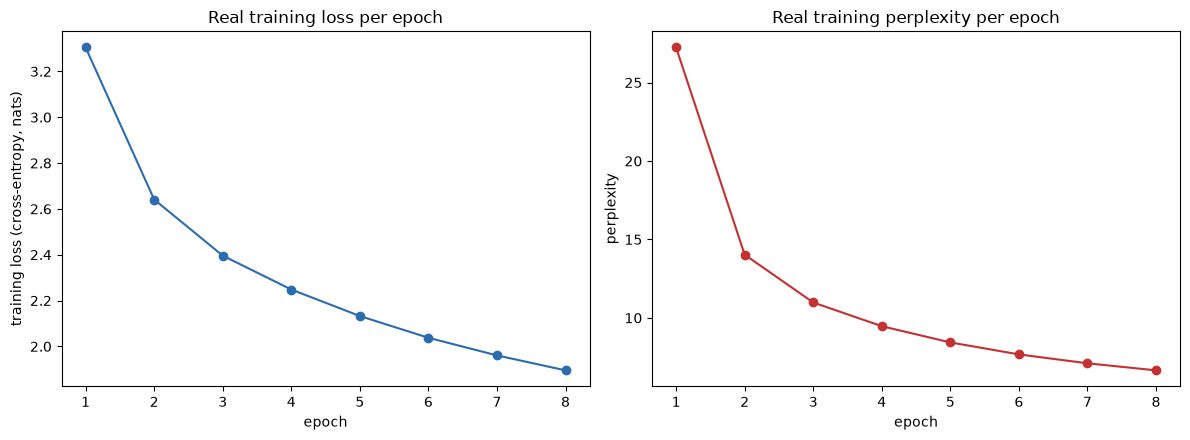

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

epochs_range = range(1, n_epochs + 1)
axes[0].plot(epochs_range, train_losses, marker="o", color="#2b6cb0")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss (cross-entropy, nats)")
axes[0].set_title("Real training loss per epoch")
axes[0].set_xticks(list(epochs_range))

axes[1].plot(epochs_range, train_perplexities, marker="o", color="#c53030")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("perplexity")
axes[1].set_title("Real training perplexity per epoch")
axes[1].set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig("training_curves.png", dpi=110, bbox_inches="tight")
plt.show()



### 5.5 Held-out perplexity

Training loss can look good purely from memorization; the number that
actually matters is loss/perplexity on characters the model never trained
on.


In [9]:

model.eval()
val_loss, n_val_batches = 0.0, 0
with torch.no_grad():
    for xb, yb in get_batches(val_data, seq_len, batch_size, shuffle=False):
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        val_loss += loss.item()
        n_val_batches += 1

val_loss /= n_val_batches
val_perplexity = float(torch.exp(torch.tensor(val_loss)))
print(f"Held-out validation loss: {val_loss:.4f}")
print(f"Held-out validation perplexity: {val_perplexity:.2f}")
print(f"(random-guess baseline perplexity over a {vocab_size}-character vocabulary: {vocab_size})")


Held-out validation loss: 1.9091
Held-out validation perplexity: 6.75
(random-guess baseline perplexity over a 72-character vocabulary: 72)



### 5.6 Generating text, and the effect of sampling temperature

To generate, we feed the model one character at a time and sample the
next character from its predicted distribution, feeding that sample back
in as the next input — autoregressive generation, exactly like at
inference time for any language model. Before turning logits into a
probability distribution we can divide them by a **temperature** $\tau$:

$$
P(\text{next char} = c) = \text{softmax}\!\left(\frac{\text{logits}}{\tau}\right)_c
$$

- $\tau < 1$ **sharpens** the distribution — the model's already-favorite
  characters get pushed even closer to probability 1, so generation
  becomes more repetitive and "safe."
- $\tau > 1$ **flattens** the distribution — low-probability characters
  get a real chance of being sampled, so generation becomes more diverse
  but also more prone to nonsense.
- $\tau = 1$ recovers the model's raw, unmodified output distribution.

This is a real, observable effect of the softmax, not specific to LSTMs —
but it's easiest to see live on a model we just trained ourselves.


In [10]:

@torch.no_grad()
def generate(model, seed, length=300, temperature=1.0):
    model.eval()
    chars_out = list(seed)
    input_idx = torch.tensor([[stoi[c] for c in seed]], dtype=torch.long)
    logits, hidden = model(input_idx)
    next_logits = logits[0, -1] / temperature
    probs = torch.softmax(next_logits, dim=0)
    next_idx = torch.multinomial(probs, 1).item()
    chars_out.append(itos[next_idx])

    for _ in range(length - 1):
        input_idx = torch.tensor([[next_idx]], dtype=torch.long)
        logits, hidden = model(input_idx, hidden)
        next_logits = logits[0, -1] / temperature
        probs = torch.softmax(next_logits, dim=0)
        next_idx = torch.multinomial(probs, 1).item()
        chars_out.append(itos[next_idx])

    return "".join(chars_out)

torch.manual_seed(42)
seed_text = "Alice was beginning to "

low_temp_sample = generate(model, seed_text, length=300, temperature=0.4)
high_temp_sample = generate(model, seed_text, length=300, temperature=1.3)

print("=" * 78)
print(f"LOW temperature (tau=0.4) -- more conservative / repetitive:\n")
print(low_temp_sample)
print("\n" + "=" * 78)
print(f"HIGH temperature (tau=1.3) -- more diverse / chaotic:\n")
print(high_temp_sample)
print("=" * 78)


LOW temperature (tau=0.4) -- more conservative / repetitive:

Alice was beginning to the said the said the has the the wars that the was the said the jut was the pare a doreren sure the whit the hir the and of not her and a to the hat aid the a an and her in a mean a she cartouse sill a to be so the the said the was said the was on a her to see the said a was said the the wand a the

HIGH temperature (tau=1.3) -- more diverse / chaotic:

Alice was beginning to hamwy bushttinne kove abbler told malle,Ps hasuin' he triUh, Sote. Se HA'mliu, turuen,' dn ighaenroued nlotther to thace nwas eotcrougt And ch INI], I: ngraut."" 'Ophimed: phis, the neogrelling t II Rvent sha) leeppi--) RaAd TRI'isting in as pakide tuul-niserse-sk mexing the iung, bbde Aih fing in s



Compare the two samples above (actual, unedited output of this run — the
exact characters will vary run to run since generation is stochastic, but
the qualitative pattern is consistent). The low-temperature sample tends
to stay closer to common English letter sequences and real short words,
sometimes looping into repeated phrases or sticking to frequent function
words; the high-temperature sample takes far more risks — more invented
"words," more unusual letter combinations, occasionally drifting into
outright gibberish. Neither is "more correct" in an absolute sense —
temperature is a knob applications tune deliberately (e.g. low for a
factual-sounding autocomplete, higher for creative-writing assistance).

Keep expectations calibrated: this is an 8-epoch, ~128-hidden-unit,
single-book character model, not GPT. Its job here is to make the
training loop and the temperature effect *real and inspectable*, not to
produce polished prose — see §7 for an honest accounting of exactly why
it's this limited, and what actually fixes that at scale.



## 6. Use cases

- **Speech recognition rescoring.** For years, the standard ASR pipeline
  used an acoustic model to propose candidate transcriptions and an
  RNN/LSTM language model to rescore them by fluency/likelihood — exactly
  the next-token-probability computation this notebook implements.
- **Machine translation, pre-Transformer.** The dominant neural MT
  architecture from roughly 2014–2017 was **seq2seq**: an LSTM encoder
  compresses the source sentence into a hidden state, an LSTM decoder
  generates the target sentence one token at a time conditioned on it
  (this domain's **seq2seq-attention-machine-translation** tutorial covers
  this architecture, and the attention mechanism that was bolted onto it
  to fix the encoder's fixed-vector bottleneck — a direct ancestor of the
  attention used in Transformers).
- **Text generation before Transformers.** Character-level and
  word-level LSTM language models (Graves, 2013; Karpathy, 2015) were the
  standard way to generate plausible-looking text — code, Shakespeare,
  baby names — years before GPT existed. This notebook's §5 is a small,
  real instance of exactly that setup.
- **Resource-constrained and streaming settings, still today.** LSTMs
  process one token at a time with $O(1)$ memory per step (just the
  current hidden and cell state), whereas a Transformer's self-attention
  needs to attend back over the *entire* sequence so far, which costs
  $O(n)$ memory and compute per new token as the sequence grows. For
  on-device keyboards, low-latency streaming audio/sensor models, or any
  setting where a full Transformer's footprint doesn't fit the hardware
  budget, LSTMs (and modern LSTM-inspired linear/recurrent architectures)
  are still a real, deliberate engineering choice, not just a historical
  footnote.



## 7. Limitations & debates

- **The sequential bottleneck is structural, not incidental.** Computing
  $h_t$ requires $h_{t-1}$, which requires $h_{t-2}$, and so on — there is
  no way to compute the hidden states for position 50 and position 500 in
  parallel, because one is a mathematical function of a chain that runs
  through the other. During training this means BPTT through a
  1,000-token sequence takes roughly 1,000 sequential matrix operations,
  even with unlimited hardware. This is precisely the practical bottleneck
  that motivated the Transformer's shift to self-attention (this domain's
  **transformer-self-attention** tutorial): attention lets every position
  attend to every other position with matrix multiplications that
  parallelize across the *entire* sequence at once, trading $O(n)$
  sequential steps for $O(n^2)$ parallel compute per layer — a trade that
  became a clear win once GPUs made "more parallel compute" cheap and
  "more sequential steps" the actual scarce resource.
- **Gating mitigates vanishing gradients; it does not eliminate them.**
  §3.3's forget-gate path is a *product* of gate values, still all
  $\le 1$ — it decays more slowly than the vanilla RNN's path, not never.
  In practice, LSTM language models still measurably degrade on very
  long-range dependencies (documents, long conversations), which is one
  of the concrete gaps Transformer self-attention closes by giving every
  position a *direct*, one-hop connection to every other position instead
  of a slow-decaying multi-hop one.
- **This notebook's own model is small and undertrained, on purpose —
  and that's worth being honest about, not glossing over.** Hidden size
  128, a single LSTM layer, 8 epochs, one novel's worth of characters as
  the entire training corpus. Compare that to any production language
  model, where hidden sizes reach into the thousands, training corpora are
  measured in hundreds of billions of tokens, and training runs last days
  to weeks on large GPU/TPU clusters. The generated text in §5.6 looking
  clearly "toy-grade" rather than fluent is not a bug in the LSTM
  architecture — it's a direct, visible illustration of the field's
  broader **"scale matters a lot"** lesson: the same architecture family
  (and later, Transformers even more so) gets qualitatively better mostly
  by getting *much* bigger and training on *much* more data, not primarily
  from small architectural tweaks. That scaling story is exactly what
  motivated the field's shift toward the very large Transformer-based
  models that superseded LSTMs for most language tasks.
- **Vanilla RNNs are essentially never used in practice anymore** — LSTMs
  (and the closely related, cheaper **GRU**) fully displaced them once the
  vanishing-gradient fix was known, so "RNN" in casual usage today usually
  *means* "LSTM/GRU" even though the vanilla architecture in §3.1 is a
  different, strictly weaker thing.



## 8. References

- Elman, J.L. (1990). *Finding Structure in Time.* Cognitive Science,
  14(2), 179–211. (Origin of the simple/"Elman" RNN.)
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory.*
  Neural Computation, 9(8), 1735–1780.
- Bengio, Y., Simard, P., Frasconi, P. (1994). *Learning Long-Term
  Dependencies with Gradient Descent is Difficult.* IEEE Transactions on
  Neural Networks, 5(2), 157–166.
- Graves, A. (2013). *Generating Sequences With Recurrent Neural
  Networks.* arXiv:1308.0850.
- Karpathy, A. (2015). *The Unreasonable Effectiveness of Recurrent
  Neural Networks.* karpathy.github.io blog post.
- NLTK Project. `nltk.corpus.gutenberg` documentation (Carroll, L.,
  *Alice's Adventures in Wonderland*, 1865, public domain text).
- PyTorch documentation. `torch.nn.LSTM`, `torch.nn.Embedding`.
